In [1]:
# Import necessary libraries
import sys
import os
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import Mars library components
import mars
from mars import spin_model, spectra_manager, mesher, constants
from mars import utils
from mars import population

# # Let's import some useful functions for plotting simulation results over time.
from mars import visualization

Some stuff might fail: issue in joblib
[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


In [117]:
dtype = torch.float64
device = torch.device("cpu")

In [149]:
mesh = mesher.CrystalMesh([0.0, 0.0, 0.0], dtype=dtype)
#mesh = mesher.DelaunayMesh(dtype=dtype)

def get_triplets():
    g_tensor = spin_model.Interaction([2.01, 2.02, 2.04], dtype=dtype, device=device)
    zfs_interaction = spin_model.DEInteraction([500.0, 10.0], dtype=dtype, device=device)  # 500 and 100 MHz

    base_spin_system = spin_model.SpinSystem(
        electrons=[1.0],  # S=1 triplet
        g_tensors=[g_tensor],
        electron_electron=[(0, 0, zfs_interaction)]
    )

    triplet_1 = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=3e7,
        gauss=0.001,
        lorentz=0.001,
        mesh=mesh,
        device=device,
        dtype=dtype
    )
    
    g_tensor = spin_model.Interaction([2.04, 2.02, 2.01], dtype=dtype, device=device)
    zfs_interaction = spin_model.DEInteraction([0.0, 0.0], dtype=dtype, device=device)  # 500 and 100 MHz
    base_spin_system = spin_model.SpinSystem(
        electrons=[1.0],  # S=1 triplet
        g_tensors=[g_tensor],
        electron_electron=[(0, 0, zfs_interaction)]
    )

    triplet_2 = spin_model.MultiOrientedSample(
        base_spin_system=base_spin_system,
        ham_strain=3e7,
        gauss=0.001,
        lorentz=0.001,
        mesh=mesh,
        device=device,
        dtype=dtype
    )
    return triplet_1, triplet_2

triplet_1, triplet_2 = get_triplets()

In [150]:
init_populations = [0.5001, 0.5, 0.5001] # Let's make them almoust equel
init_populations  = [pop / sum(init_populations) for pop in init_populations]

out_probs = torch.tensor([1.0, 1.0, 1.0], device=device, dtype=dtype) * 100 # 10 ms is some depopulation time

# Level 0 ↔ Level 1 and Level 1 ↔ Level 2 at 1000 s⁻¹ (~1 ms equilibration).
# Note that you do not need to specify the diagonal elements manually, they are set automatically during calculations.
free_probs = torch.tensor([[0.0, 1.0, 0.0],
                           [1.0, 0.0, 1.0],
                           [0.0, 1.0, 0.0]], device=device, dtype=dtype) * 1000 # 1 ms is time of equilibration for triplet relaxation.

# No driven transitions in this example
driven_probs = None # Do not consider it here.


init_density = torch.zeros((3, 3), dtype=torch.complex128, device=device)


context_pops = population.Context(
    sample=triplet_1, basis="eigen", init_populations=init_populations,
    out_probs=out_probs, free_probs=free_probs, device=device, dtype=dtype
)

context_deph = population.Context(sample=triplet_1, dephasing=[1e5, 1e5, 1e5], basis="eigen", device=device, dtype=dtype)

context = context_pops + context_deph

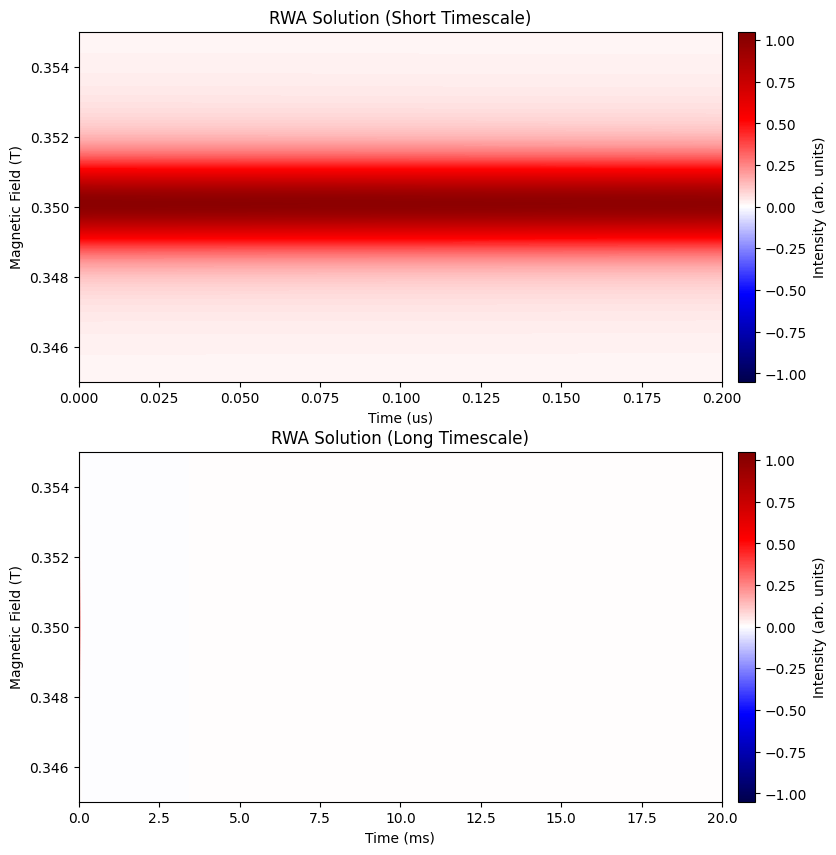

In [151]:
fields = torch.linspace(0.345, 0.355, 1000, dtype=dtype, device=device)  # Field in Tesla

# Time axes in long and short time scale
tot_points = 800
time_long = torch.linspace(0.0, 2e-2, tot_points, dtype=dtype, device=device)  # time in seconds, long time scale, up to 20ms
time_short = torch.linspace(0.0, 0.2e-6, tot_points, dtype=dtype, device=device)  # time in seconds, short time scale, up to 300µs


# Compute spectra
tr_spectra_creator_rwa = spectra_manager.DensityTimeSpectra(
    freq=9.8e9,    # Frequency in Hz 
    sample=triplet_1,
    harmonic=0, # absorbtion
    context=context,
    temperature=300.0,
   populator = "propagator", # Define propagator approach to compute spectra
   hamiltonian_mode="direct",  
    device=device,
    dtype=dtype
)

spectrum_rwa_short = tr_spectra_creator_rwa(triplet_1, fields, time_short)
spectrum_rwa_long = tr_spectra_creator_rwa(triplet_1, fields, time_long)

# Normalize using long-time scale max
normalization_rwa = np.max(np.abs(spectrum_rwa_long.cpu().numpy()))
spectrum_rwa_long_np = spectrum_rwa_long.cpu().numpy() / normalization_rwa
spectrum_rwa_short_np = spectrum_rwa_short.cpu().numpy() / normalization_rwa

# Plotting
fig, (ax_short, ax_long) = plt.subplots(2, 1, figsize=(10, 10), sharex=False)

# Short timescale
plt.sca(ax_short)
visualization.plot_2d_timeresolved(
    fields, time_short, spectrum_rwa_short_np,
    time_unit="us",
)
plt.title("RWA Solution (Short Timescale)")

# Long timescale
plt.sca(ax_long)
visualization.plot_2d_timeresolved(
    fields, time_long, spectrum_rwa_long_np,
    time_unit="ms",
)
plt.title("RWA Solution (Long Timescale)")
plt.show()